In [5]:
import numpy as np
import numpy.random as rnd
from numba import njit
import matplotlib.pyplot as plt
from scipy.stats import norm

In [28]:
coords = np.asarray([2*rnd.random(3) for _ in range(5)])
n, D = coords.shape
print(f"n = {n}, D = {D}")
print(coords)

n = 5, D = 3
[[0.31855825 1.27481329 0.94664433]
 [1.35007222 1.59099805 0.46433257]
 [0.8440597  1.79076333 0.75104692]
 [0.54510211 1.51854691 1.59875766]
 [1.33807039 1.28653211 1.07859544]]


In [78]:
toadd = np.asarray([[0, 1 , 0] for _ in range(5)])
coords += np.asarray([[1]+[0]*(D-1) for _ in range(5)])
print(coords)

[[27.31855825 23.27481329  0.94664433]
 [28.35007222 23.59099805  0.46433257]
 [27.8440597  23.79076333  0.75104692]
 [27.54510211 23.51854691  1.59875766]
 [28.33807039 23.28653211  1.07859544]]


In [121]:
x, y, z = coords[0]
print(f"{x}, {y}, {z}")

1.9044483183254983, 0.9199226407246319, 0.8541038406538923


In [122]:
temp = coords[0]
print(temp)

[1.90444832 0.91992264 0.85410384]


In [126]:
temp - coords[2]

array([ 0.75130065,  0.70198627, -0.09670424])

In [135]:
a = np.asarray([3,4])
np.linalg.norm(temp - coords[1])

1.9730854785004919

In [136]:
np.zeros(5)

array([0., 0., 0., 0., 0.])

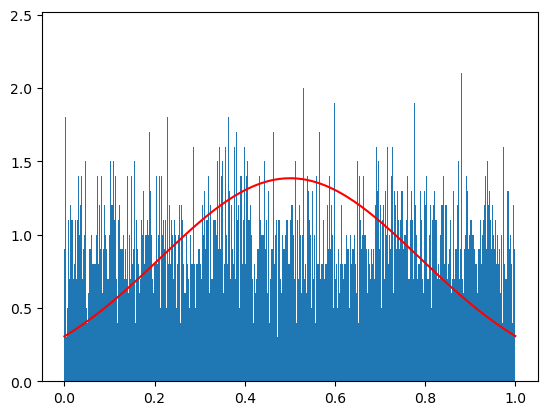

In [21]:
x = rnd.random(100000)
plt.hist(x, bins=10000, density=True)
mu, sigma = np.mean(x), np.std(x)
xx = np.linspace(x.min(), x.max(), 200)
plt.plot(xx, norm.pdf(xx, mu, sigma), color='red')
plt.show()


In [9]:
xx = np.linspace(0, 1, 101)
print(xx)

[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99 1.  ]


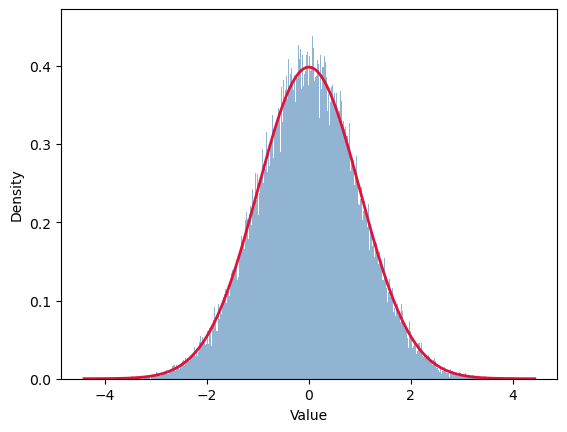

In [14]:
data = np.random.normal(size=100000)

fig, ax = plt.subplots()
ax.hist(data, bins=1000, density=True, alpha=0.6, color="steelblue")

x = np.linspace(data.min(), data.max(), 200)
ax.plot(x, norm.pdf(x, data.mean(), data.std()), color="crimson", lw=2)

ax.set_xlabel("Value")
ax.set_ylabel("Density")
plt.show()

In [100]:
rnd.uniform(-1,1,3)

array([ 0.83813343, -0.35942176,  0.14032787])

In [168]:
center = np.asarray([5,0,5])
coords = np.zeros((2,3))
coords[0] = rnd.uniform(-1,1,3)
coords += center
print(coords)

[[5.87276093 0.80014697 5.10840855]
 [5.         0.         5.        ]]


In [169]:
[5]*3

[5, 5, 5]

In [176]:
coords = rnd.uniform(-1,1,(10, 3))
coords

array([[-6.67703916e-01,  8.01931642e-02, -9.39290954e-01],
       [-5.84039138e-01, -2.12354974e-01, -3.28418698e-01],
       [-1.63156168e-01,  2.15135897e-01, -9.33961567e-04],
       [ 8.62066138e-01,  2.52450767e-01, -9.93398707e-01],
       [-8.63271940e-01, -8.37837567e-01, -7.92291305e-01],
       [ 2.89389458e-01, -5.81563536e-01,  5.47089403e-01],
       [ 5.42969021e-01, -9.39443587e-01, -6.60256137e-01],
       [-1.93671524e-01,  3.20615004e-01,  8.44696579e-01],
       [-6.15282333e-01, -6.58954586e-02,  6.53196235e-01],
       [ 2.22614542e-01, -8.47909551e-01, -6.51879312e-04]])

In [191]:
coords = np.asarray([[10*n + j for j in range(3)] for n in range(5)])
print(coords)
coords * coords

[[ 0  1  2]
 [10 11 12]
 [20 21 22]
 [30 31 32]
 [40 41 42]]


array([[   0,    1,    4],
       [ 100,  121,  144],
       [ 400,  441,  484],
       [ 900,  961, 1024],
       [1600, 1681, 1764]])

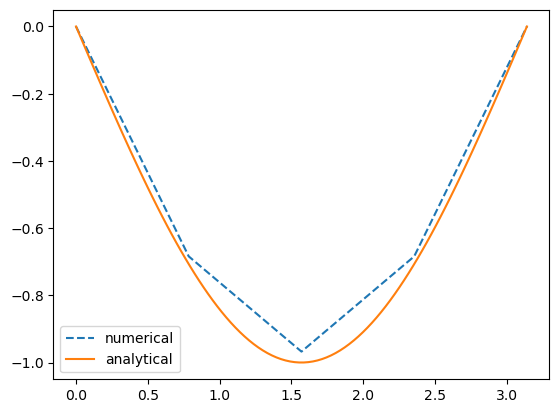

In [210]:
# comparing numerical second derivative with analytical second derivative
def f(x):
    return np.sin(x)
def d2f_dx2_analytical(xs):
    return -np.sin(xs)
def d2f_dx2_numerical(x, h=1):
    return (f(x + h) - 2*f(x) + f(x - h)) / (h**2)
domain = 1*np.pi
n = 5
h = domain/n
xs_num = np.linspace(0, domain, n)
xs_ana = np.linspace(0, domain, 100)
plt.figure()
plt.plot(xs_num, [d2f_dx2_numerical(x, h) for x in xs_num], label="numerical", linestyle='dashed')
plt.plot(xs_ana, d2f_dx2_analytical(xs_ana), label="analytical")
plt.legend()
plt.show()